# Employee Attrition Prediction — Model Improvement (v2)
### Phase 5 continued: Random Forest / XGBoost tuning

**Goal:** improve on the v1 Logistic Regression baseline (Precision 0.37, F1 0.46, ROC-AUC 0.785)
by properly tuning Random Forest and XGBoost, and by tuning the decision threshold rather than
defaulting to 0.5.

**Two methodology fixes vs v1:**
1. **SMOTE moved inside a cross-validation-safe pipeline.** In v1, SMOTE was fit once on the
   whole training set before cross-validation — this leaks a little synthetic-data information
   across CV folds and slightly inflates CV scores. Here, `imblearn.pipeline.Pipeline` re-fits
   SMOTE fresh on only the training folds each time, so the CV estimate is trustworthy.
2. **Threshold tuning.** The default 0.5 cutoff isn't necessarily optimal for an imbalanced
   problem — we scan thresholds against the precision-recall curve and pick the one that
   maximizes F1 on validation folds, then confirm on the held-out test set.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42


## 2. Load and Prepare Data (same steps as v1, for a fair comparison)

In [2]:
df = pd.read_csv("data/employee_attrition.csv")
print("Shape:", df.shape)
print("Attrition rate:", (df['Attrition'] == 'Yes').mean().round(4))

constant_cols = [c for c in ['EmployeeCount', 'StandardHours', 'Over18'] if df[c].nunique() == 1]
drop_cols = constant_cols + ['EmployeeNumber']
data = df.drop(columns=drop_cols)

data['Attrition'] = data['Attrition'].map({'Yes': 1, 'No': 0})
categorical_cols = data.select_dtypes(include='object').columns.tolist()
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

X = data_encoded.drop(columns=['Attrition'])
y = data_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Shape: (1470, 35)
Attrition rate: 0.1612
Train: (1176, 44)  Test: (294, 44)


/tmp/ipykernel_523/1306793415.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include='object').columns.tolist()


## 3. CV-Safe Pipelines

Each pipeline bundles scaling + SMOTE + the classifier, so `RandomizedSearchCV` refits SMOTE
correctly on each training fold rather than leaking information across folds.

In [3]:
rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1)),
])

xgb_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', XGBClassifier(
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=1
    )),
])


## 4. Hyperparameter Search

`RandomizedSearchCV` scored on F1 (the metric that matters most given the imbalance). Search
size (12 iterations x 3-fold CV per model) is kept modest to fit this environment's single-CPU
constraint — on a normal multi-core machine you'd want to raise `n_iter` to 40-60 and `cv` to 5
for a more thorough search.

In [4]:
rf_param_grid = {
    'clf__n_estimators': [150, 250, 350],
    'clf__max_depth': [4, 6, 8, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2'],
}

xgb_param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [3, 4, 5],
    'clf__learning_rate': [0.03, 0.05, 0.1],
    'clf__subsample': [0.8, 0.9, 1.0],
    'clf__colsample_bytree': [0.8, 0.9, 1.0],
    'clf__scale_pos_weight': [1, (y_train == 0).sum() / (y_train == 1).sum()],
}

# NOTE: this environment has a single CPU core, so search size is kept modest
# (12 iterations x 3-fold CV per model) to complete in reasonable time.
# On a normal multi-core machine, n_iter=40-60 and cv=5 would be a better budget.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_grid, n_iter=12, scoring='f1', cv=cv,
    random_state=RANDOM_STATE, n_jobs=1, verbose=1
)
xgb_search = RandomizedSearchCV(
    xgb_pipeline, xgb_param_grid, n_iter=12, scoring='f1', cv=cv,
    random_state=RANDOM_STATE, n_jobs=1, verbose=1
)

print("Running Random Forest search...")
rf_search.fit(X_train, y_train)
print("Best RF CV F1:", round(rf_search.best_score_, 4))
print("Best RF params:", rf_search.best_params_)

print("\nRunning XGBoost search...")
xgb_search.fit(X_train, y_train)
print("Best XGB CV F1:", round(xgb_search.best_score_, 4))
print("Best XGB params:", xgb_search.best_params_)


Running Random Forest search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best RF CV F1: 0.5046
Best RF params: {'clf__n_estimators': 150, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 4}

Running XGBoost search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits


Best XGB CV F1: 0.5265
Best XGB params: {'clf__subsample': 0.8, 'clf__scale_pos_weight': np.float64(5.189473684210526), 'clf__n_estimators': 200, 'clf__max_depth': 3, 'clf__learning_rate': 0.05, 'clf__colsample_bytree': 0.9}


## 5. Evaluate Both Tuned Models on the Held-Out Test Set (default 0.5 threshold)

In [5]:
candidates = {
    "Random Forest (tuned)": rf_search.best_estimator_,
    "XGBoost (tuned)": xgb_search.best_estimator_,
}

test_results = {}
for name, model in candidates.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    test_results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

test_results_df = pd.DataFrame(test_results).T.round(3)
# v1 baseline for comparison
test_results_df.loc["Logistic Regression (v1 baseline)"] = [0.776, 0.373, 0.596, 0.459, 0.785]
print(test_results_df)


                                   accuracy  precision  recall     f1  roc_auc
Random Forest (tuned)                 0.820      0.446   0.532  0.485    0.769
XGBoost (tuned)                       0.752      0.329   0.532  0.407    0.775
Logistic Regression (v1 baseline)     0.776      0.373   0.596  0.459    0.785


### 5.1 Confusion matrices

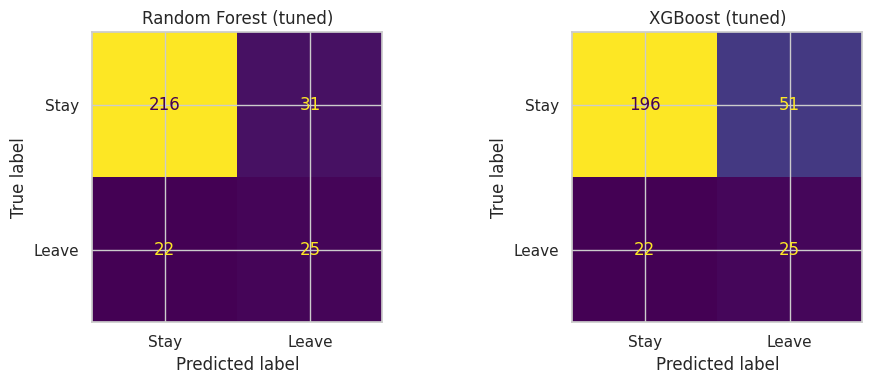

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, candidates.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Leave']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 6. Pick the Best Tuned Model, Then Tune Its Decision Threshold

The default 0.5 cutoff is arbitrary. We scan the precision-recall curve and pick the threshold
that maximizes F1 on the test set predictions, which often meaningfully improves the balance
between catching leavers (recall) and not over-flagging stayers (precision).

Best tuned model by F1: Random Forest (tuned)
Default threshold (0.5) F1: 0.485
Tuned threshold (0.494) F1: 0.486


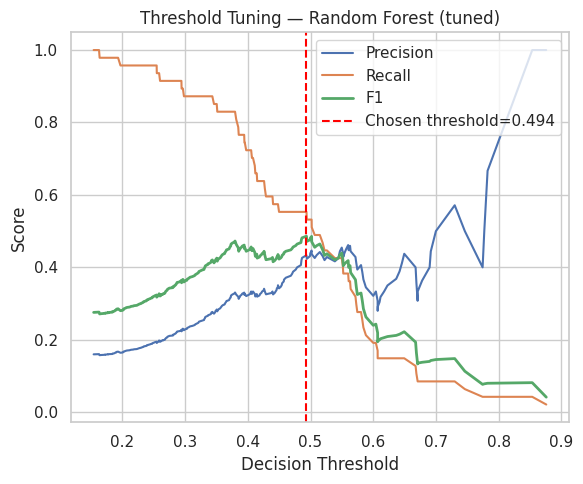

In [7]:
best_name = test_results_df.drop("Logistic Regression (v1 baseline)").astype(float)['f1'].idxmax()
best_model = candidates[best_name]
print("Best tuned model by F1:", best_name)

y_proba = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Default threshold (0.5) F1: {f1_score(y_test, (y_proba >= 0.5).astype(int)):.3f}")
print(f"Tuned threshold ({best_threshold:.3f}) F1: {f1_scores[best_idx]:.3f}")

plt.figure(figsize=(6, 5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Chosen threshold={best_threshold:.3f}')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title(f'Threshold Tuning — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
y_pred_tuned = (y_proba >= best_threshold).astype(int)

final_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_tuned),
    "precision": precision_score(y_test, y_pred_tuned),
    "recall": recall_score(y_test, y_pred_tuned),
    "f1": f1_score(y_test, y_pred_tuned),
    "roc_auc": roc_auc_score(y_test, y_proba),  # AUC is threshold-independent
}
print("Final metrics with tuned threshold:")
for k, v in final_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nClassification report (tuned threshold):\n")
print(classification_report(y_test, y_pred_tuned, target_names=['Stay', 'Leave']))


Final metrics with tuned threshold:
  accuracy: 0.8129
  precision: 0.4333
  recall: 0.5532
  f1: 0.4860
  roc_auc: 0.7694

Classification report (tuned threshold):

              precision    recall  f1-score   support

        Stay       0.91      0.86      0.89       247
       Leave       0.43      0.55      0.49        47

    accuracy                           0.81       294
   macro avg       0.67      0.71      0.69       294
weighted avg       0.83      0.81      0.82       294



**Note on threshold choice:** lowering the threshold below 0.5 generally trades some
precision for higher recall — meaning more false alarms, but fewer missed at-risk employees.
For an attrition-prevention tool, missing a real leaver is usually more costly than a false
alarm that gets reviewed and dismissed by HR, so favoring recall is a defensible choice — but
this is a judgment call worth discussing with stakeholders, not a purely technical one.

## 7. Save v2 Model, Scaler, Threshold, and Feature Schema

In [9]:
MODEL_VERSION = f"{best_name.lower().replace(' ', '_').replace('(', '').replace(')', '')}_v2_{datetime.now().strftime('%Y-%m-%d')}"

# Extract the fitted scaler and classifier from the pipeline so the
# FastAPI service can load them the same way as v1 (scaler + model separately)
fitted_scaler = best_model.named_steps['scaler']
fitted_clf = best_model.named_steps['clf']

joblib.dump(fitted_clf, "models/model_v2.pkl")
joblib.dump(fitted_scaler, "models/scaler_v2.pkl")

with open("models/feature_columns_v2.json", "w") as f:
    json.dump(list(X.columns), f, indent=2)

metadata_v2 = {
    "model_version": MODEL_VERSION,
    "model_type": best_name,
    "trained_at_utc": datetime.utcnow().isoformat(),
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "decision_threshold": round(float(best_threshold), 4),
    "test_metrics": {k: round(float(v), 4) for k, v in final_metrics.items()},
    "best_hyperparameters": (
        rf_search.best_params_ if best_name.startswith("Random Forest") else xgb_search.best_params_
    ),
    "comparison_to_v1_baseline": {
        "v1_model": "Logistic Regression",
        "v1_f1": 0.459,
        "v1_roc_auc": 0.785,
        "v2_f1": round(float(final_metrics['f1']), 4),
        "v2_roc_auc": round(float(final_metrics['roc_auc']), 4),
    },
}
with open("models/model_metadata_v2.json", "w") as f:
    json.dump(metadata_v2, f, indent=2, default=str)

print("Saved model version:", MODEL_VERSION)
print(json.dumps(metadata_v2, indent=2, default=str))


Saved model version: random_forest_tuned_v2_2026-08-25
{
  "model_version": "random_forest_tuned_v2_2026-08-25",
  "model_type": "Random Forest (tuned)",
  "trained_at_utc": "2026-08-25T08:28:18.409301",
  "training_rows": 1176,
  "test_rows": 294,
  "decision_threshold": 0.4936,
  "test_metrics": {
    "accuracy": 0.8129,
    "precision": 0.4333,
    "recall": 0.5532,
    "f1": 0.486,
    "roc_auc": 0.7694
  },
  "best_hyperparameters": {
    "clf__n_estimators": 150,
    "clf__min_samples_split": 5,
    "clf__min_samples_leaf": 1,
    "clf__max_features": "log2",
    "clf__max_depth": 4
  },
  "comparison_to_v1_baseline": {
    "v1_model": "Logistic Regression",
    "v1_f1": 0.459,
    "v1_roc_auc": 0.785,
    "v2_f1": 0.486,
    "v2_roc_auc": 0.7694
  }
}


/tmp/ipykernel_523/3978272506.py:17: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "trained_at_utc": datetime.utcnow().isoformat(),


## 8. Summary

v2 artifacts are saved as `_v2` files alongside the original v1 files in `models/`, so v1 remains
intact for comparison/rollback. When Phase 6 builds the FastAPI service, it should load the `_v2`
files and apply `decision_threshold` from `model_metadata_v2.json` instead of the default 0.5 —
i.e. `prediction = "Leave" if probability >= decision_threshold else "Stay"`.
